<a href="https://colab.research.google.com/github/DiPolanski/IA/blob/main/RandomForest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!git clone https://github.com/DiPolanski/IA.git

Cloning into 'IA'...
remote: Enumerating objects: 24, done.
remote: Counting objects: 100% (24/24), done.
remote: Compressing objects: 100% (21/21), done.
remote: Total 24 (delta 6), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (24/24), 212.83 KiB | 6.26 MiB/s, done.
Resolving deltas: 100% (6/6), done.


In [18]:

%cd /content/IA
!ls
caminho_base = '/content/IA/base_pré_processada.csv'
print(caminho_base)

/content/IA
Balancemento_SMOTE.ipynb  heart-disease.csv   RandomForest.ipynb
base_pré_processada.csv   outliers_KNN.ipynb  README.md
/content/IA/base_pré_processada.csv


In [20]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

In [21]:
data = pd.read_csv(caminho_base)


In [22]:
print("Primeiras linhas do dataset:")
print(data.head())

Primeiras linhas do dataset:
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   63    1   3       145   233    1        0      150      0      2.3      0   
1   37    1   2       130   250    0        1      187      0      3.5      0   
2   41    0   1       130   204    0        0      172      0      1.4      2   
3   56    1   1       120   236    0        1      178      0      0.8      2   
4   57    1   0       140   192    0        1      148      0      0.4      1   

   ca  thal  target  
0   0     1       1  
1   0     2       1  
2   0     2       1  
3   0     2       1  
4   0     1       1  


Separando a variável alvo ('target') das variáveis preditoras:

In [24]:
X = data.drop(columns=['target'])
y = data['target']

Dividindo os dados em conjuntos de treino e teste (80% treino, 20% teste):

In [25]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [26]:
rf_model = RandomForestClassifier(random_state=42, n_estimators=100)
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [27]:
y_pred = rf_model.predict(X_test)

In [28]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Acurácia do modelo: {accuracy:.2f}")

Acurácia do modelo: 0.88


In [29]:
print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred))


Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.96      0.80      0.87        30
           1       0.83      0.97      0.89        30

    accuracy                           0.88        60
   macro avg       0.89      0.88      0.88        60
weighted avg       0.89      0.88      0.88        60



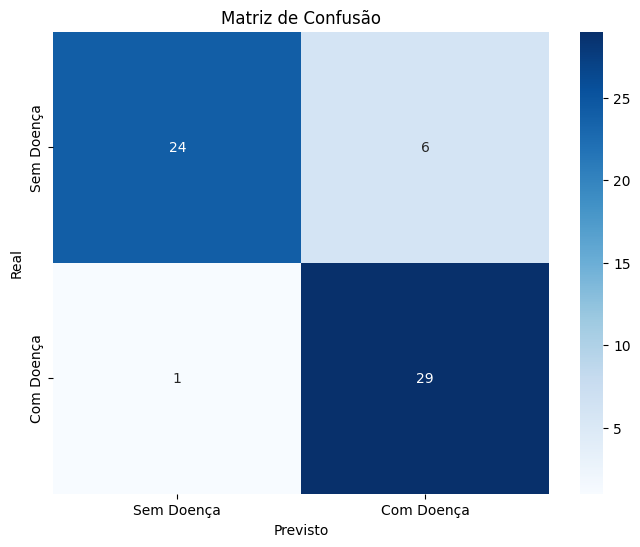

In [30]:
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=['Sem Doença', 'Com Doença'],
            yticklabels=['Sem Doença', 'Com Doença'])
plt.title("Matriz de Confusão")
plt.xlabel("Previsto")
plt.ylabel("Real")
plt.show()


In [31]:
feature_importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)

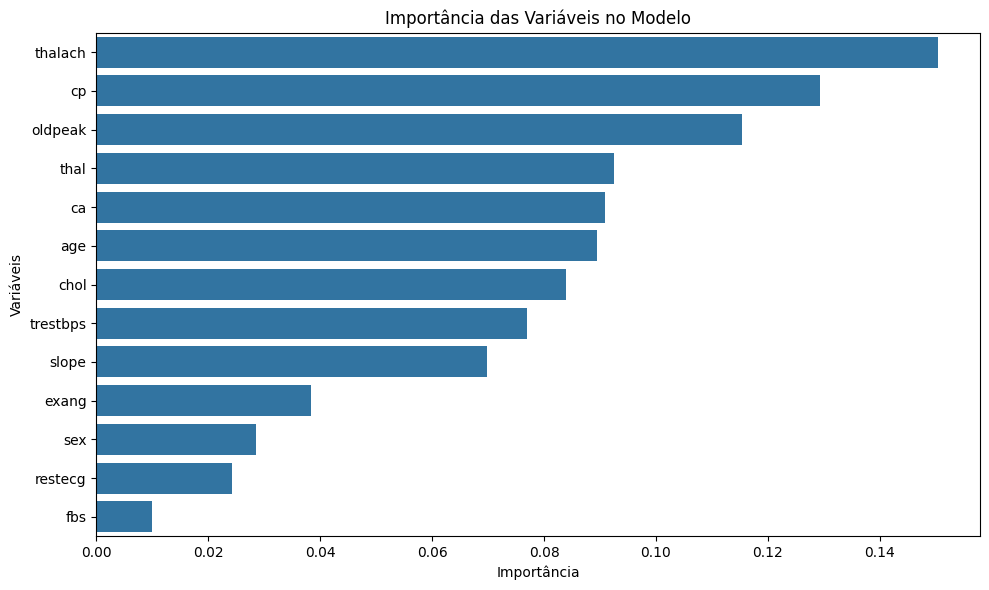

In [32]:
plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importances.values, y=feature_importances.index)
plt.title('Importância das Variáveis no Modelo')
plt.xlabel('Importância')
plt.ylabel('Variáveis')
plt.tight_layout()
plt.show()

In [33]:
print("\nImportância das Variáveis:")
print(feature_importances)


Importância das Variáveis:
thalach     0.150380
cp          0.129383
oldpeak     0.115410
thal        0.092504
ca          0.090879
age         0.089544
chol        0.083941
trestbps    0.077024
slope       0.069763
exang       0.038337
sex         0.028620
restecg     0.024243
fbs         0.009972
dtype: float64
